In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
x_train = pd.read_csv('/home/pratham/Disk2/Projects/ml_projects/loan_prediction/data/processed/x_train.csv')
x_test = pd.read_csv('/home/pratham/Disk2/Projects/ml_projects/loan_prediction/data/processed/x_test.csv')
y_train = pd.read_csv('/home/pratham/Disk2/Projects/ml_projects/loan_prediction/data/processed/y_train.csv')
y_test = pd.read_csv('/home/pratham/Disk2/Projects/ml_projects/loan_prediction/data/processed/y_test.csv')

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
)

In [4]:
rf_model.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [5]:
y_pred = rf_model.predict(x_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.49%


In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.66      0.68        38
           1       0.85      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.77       123
weighted avg       0.80      0.80      0.80       123



Text(0.5, 1.0, 'Confusion Matrix')

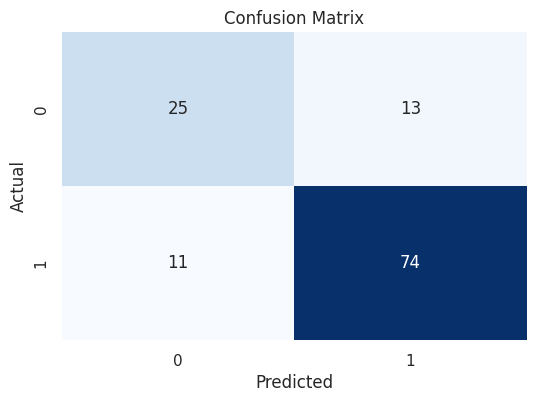

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

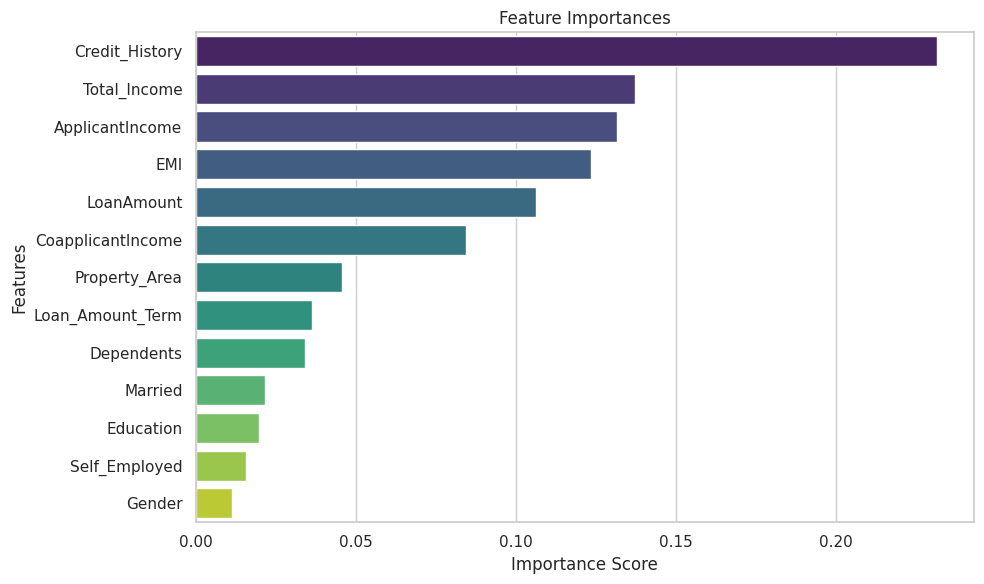

In [9]:
feature_importances = pd.Series(rf_model.feature_importances_, index=x_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [10]:
model_path = '/home/pratham/Disk2/Projects/ml_projects/loan_prediction/models/rf_model.pkl'
joblib.dump(rf_model, model_path)
print(f"Model saved to {model_path}.")

Model saved to /home/pratham/Disk2/Projects/ml_projects/loan_prediction/models/rf_model.pkl.
